In [28]:
# Load a feature path
import torch
con_snmf_feature_path = "/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/cifar100/train/concept/redefine_activations_text_grounding_simple_combined_concept_simple_gl_regrounded.pth"
snmf_cifar100_path = "/mnt/abka03/concept_extraction_result/publish/gemma3n/CGDL/SNMF/cifar100/train/concept/redefine_activations_text_grounding_sae2_combined_concept_sae2_gl_regrounded.pth"
def extract_groundings_and_concepts(feature_path):
    # Load the data from the .pth file
    data = torch.load(feature_path, map_location="cpu")
    
    # Extract concepts and groundings
    concepts = data["concepts"]
    groundigs = data["text_grounding"]
    
    # Process groundings
    processed_groundings = []
    for grounding in groundigs:
        unique_groundings = set(g.lower() for g in grounding)
        filtered_groundings = set()
        for g in unique_groundings:
            # Ensure that the filtering logic checks for substring matches correctly
            if not any(g in other and g != other for other in unique_groundings):
                filtered_groundings.add(g)
        # Sort the filtered groundings to ensure consistent order
        processed_groundings.append("_".join(set(filtered_groundings)))
    
    return concepts, processed_groundings

# Example usage
concept_before, groundigs_before = extract_groundings_and_concepts(con_snmf_feature_path)
print("First 10 groundings:", groundigs_before[:500])

concepts_after, groundigs_after = extract_groundings_and_concepts(snmf_cifar100_path)

First 10 groundings: ['vertical_chun_dung_longitudinal_saucer', 'camera_touch_rep_dialect_flexibility', 'aquaculture_aquatic_aria_arist_fish', '', 'dangerous_question_samp_wan_blind', 'raya_priestly_rayon', 'offset_hale', '', 'sealer_sealant_sealing_sealed', 'mountainous', 'successful', 'impure_upward_unknown_tow_tarmac', 'response_root_rote_natural_ping', 'phu_desk_kier', 'animate_clock', 'bridged_bridging', '', 'cycling_bike_bicycle', 'ast_aver', 'term_otter', 'reef_ruby_rum_reve_recursive', 'hop_serial_folder_pant_pinning', 'raccoon', 'telephone', 'board_pipe_chess_fine_toilet', 'delf_dolphin', 'cinema_left_script_core_dawn', '', 'revered_advisable_exalted_majestic_catfish', 'angry', 'tree_equity_oak', 'plated_plating_platelet', 'roadside_roadway', 'mushroom_fungi', 'lionel', 'ware_rope_wardrobe', 'skyscraper_sir_synchronized_symbol_fourth', 'boy', 'bottling_bottled_botella', 'scur_squire_squirrel_squaring_sprint', 'gender_general_scaled_flower_water', 'armchair_chairmanship', '', '

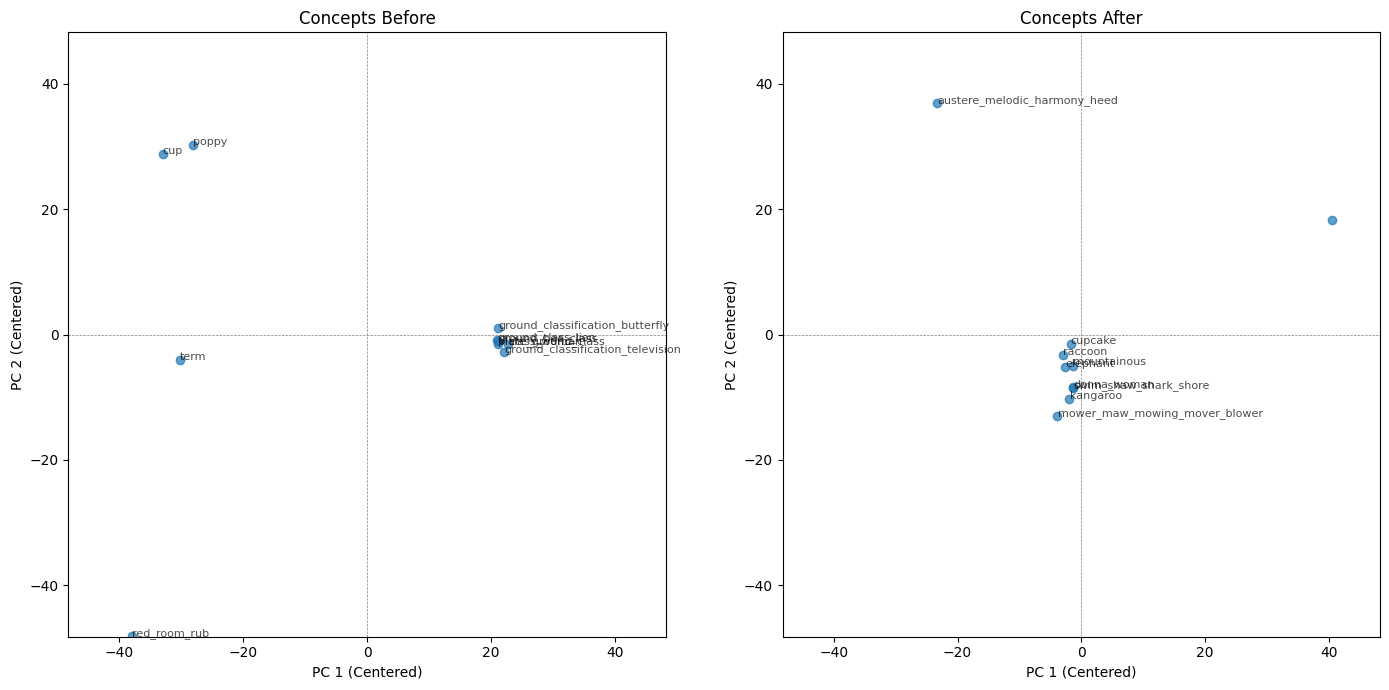

In [26]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def prepare_pca_data(concepts, groundings, sample_indices):
    # Convert to numpy and scale
    concepts_np = concepts.numpy()
    scaler = StandardScaler()
    scaled_concepts = scaler.fit_transform(concepts_np)

    # Use fixed sample
    sample_concepts = scaled_concepts[sample_indices]
    sample_groundings = [groundings[i] for i in sample_indices]

    # PCA
    pca = PCA(n_components=2)
    concepts_2d = pca.fit_transform(sample_concepts)

    # Center PCA output
    concepts_2d -= np.mean(concepts_2d, axis=0)

    return concepts_2d, sample_groundings

def plot_pca_side_by_side(data1, labels1, data2, labels2, show_labels=True, title1="Before", title2="After", output_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Consistent scaling
    combined = np.vstack((data1, data2))
    max_range = np.abs(combined).max()
    axis_limit = (-max_range - 0.1, max_range + 0.1)

    def plot(ax, data, labels, title):
        ax.scatter(data[:, 0], data[:, 1], alpha=0.7)
        if show_labels:
            for x, y, label in zip(data[:, 0], data[:, 1], labels):
                ax.text(x + 0.02, y + 0.02, str(label), fontsize=8, alpha=0.7)
        ax.set_title(title)
        ax.set_xlim(axis_limit)
        ax.set_ylim(axis_limit)
        ax.set_xlabel("PC 1 (Centered)")
        ax.set_ylabel("PC 2 (Centered)")
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
        ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)

    plot(axes[0], data1, labels1, title1)
    plot(axes[1], data2, labels2, title2)

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=300)
    plt.show()
    plt.close()

# === Example usage ===

# Set reproducible sample indices
random.seed(1008)
n_samples = 10
total_samples = len(concept_before)
sample_indices = random.sample(range(total_samples), n_samples)

# Apply PCA using the same indices
concepts_2d_before, labels_before = prepare_pca_data(concept_before, groundigs_before, sample_indices)
concepts_2d_after, labels_after = prepare_pca_data(concepts_after, groundigs_after, sample_indices)

# Plot
plot_pca_side_by_side(
    concepts_2d_before, labels_before,
    concepts_2d_after, labels_after,
    show_labels=True,
    title1="Concepts Before",
    title2="Concepts After",
    output_path="/mnt/abka03/Projects/xl-vlms/plots/mcox/concept_pca/pca_comparison_same_samples.png"
)


In [4]:
feature_path = "/mnt/abka03/concept_extraction_result/MCoX/SNMF/layer_norm_imagenet32/train/concept/combined_concept_raw.pth"
data = torch.load(feature_path, map_location="cpu")

X_lap = data["concepts"]
names = data["text_grounding"]

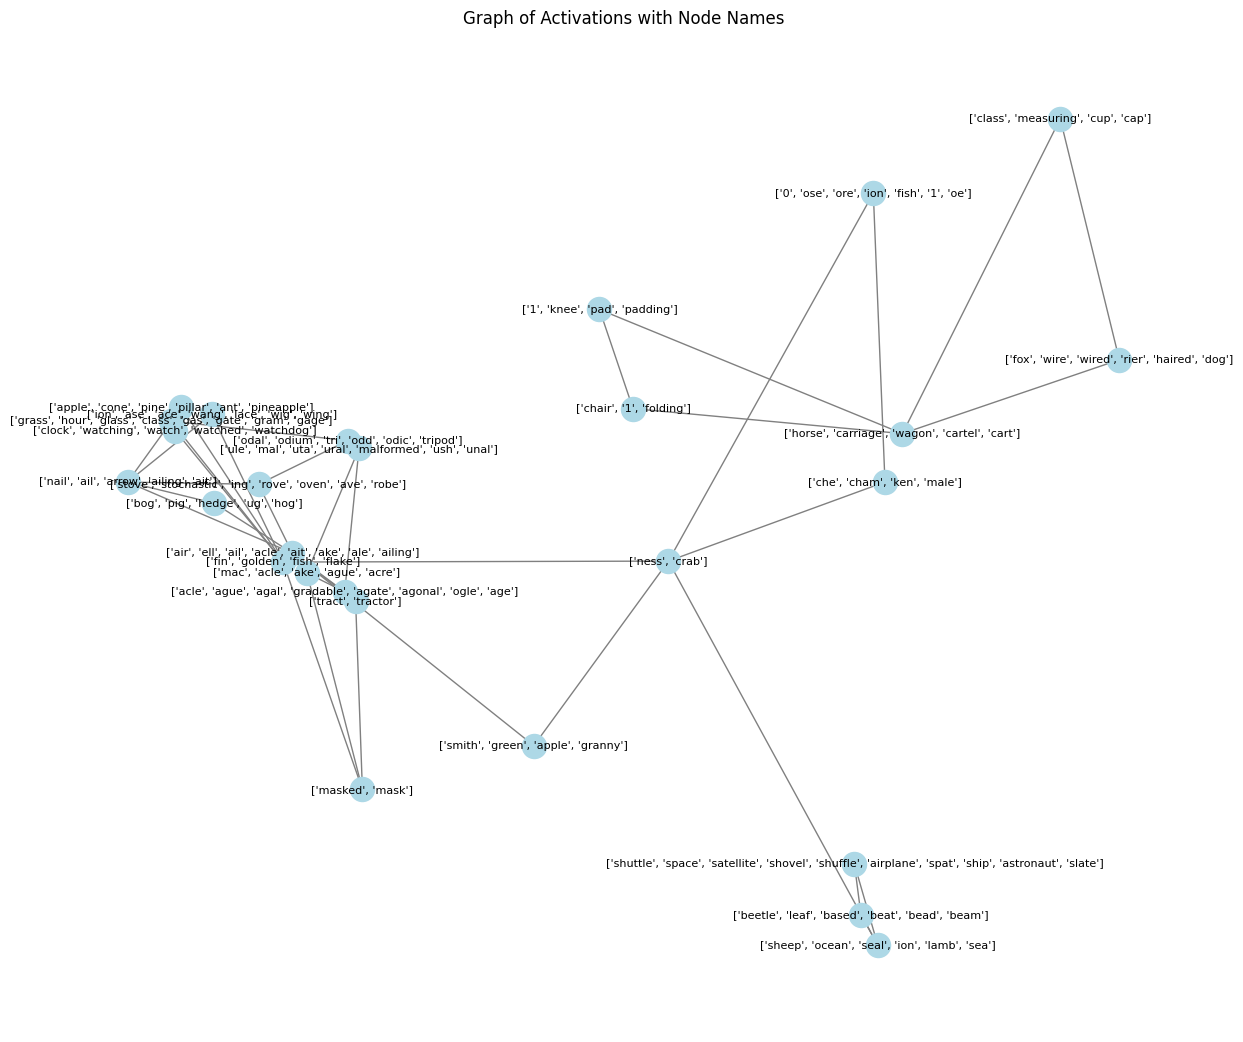

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.neighbors import kneighbors_graph
from sklearn.decomposition import PCA

# Example inputs (replace with your own)
# X_lap = np.random.rand(100, 10)
# names = [f"node_{i}" for i in range(100)]  # or your actual labels/names

# Step 1: Build the k-NN graph
knn_graph = kneighbors_graph(X_lap, n_neighbors=2, mode='connectivity', include_self=False)
adj_matrix = knn_graph.toarray()
G = nx.from_numpy_array(adj_matrix)

# Step 2: Layout positions (PCA to 2D)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_lap)
pos = {i: X_2d[i] for i in range(len(X_2d))}

# Step 3: Plot the graph with names
plt.figure(figsize=(12, 10))
nx.draw(G, pos, node_size=300, node_color='lightblue', edge_color='gray', with_labels=False)

# Add labels manually
for i, name in enumerate(names):
    x, y = pos[i]
    plt.text(x, y, name, fontsize=8, ha='center', va='center', color='black')

plt.title("Graph of Activations with Node Names")
plt.axis('off')
plt.show()


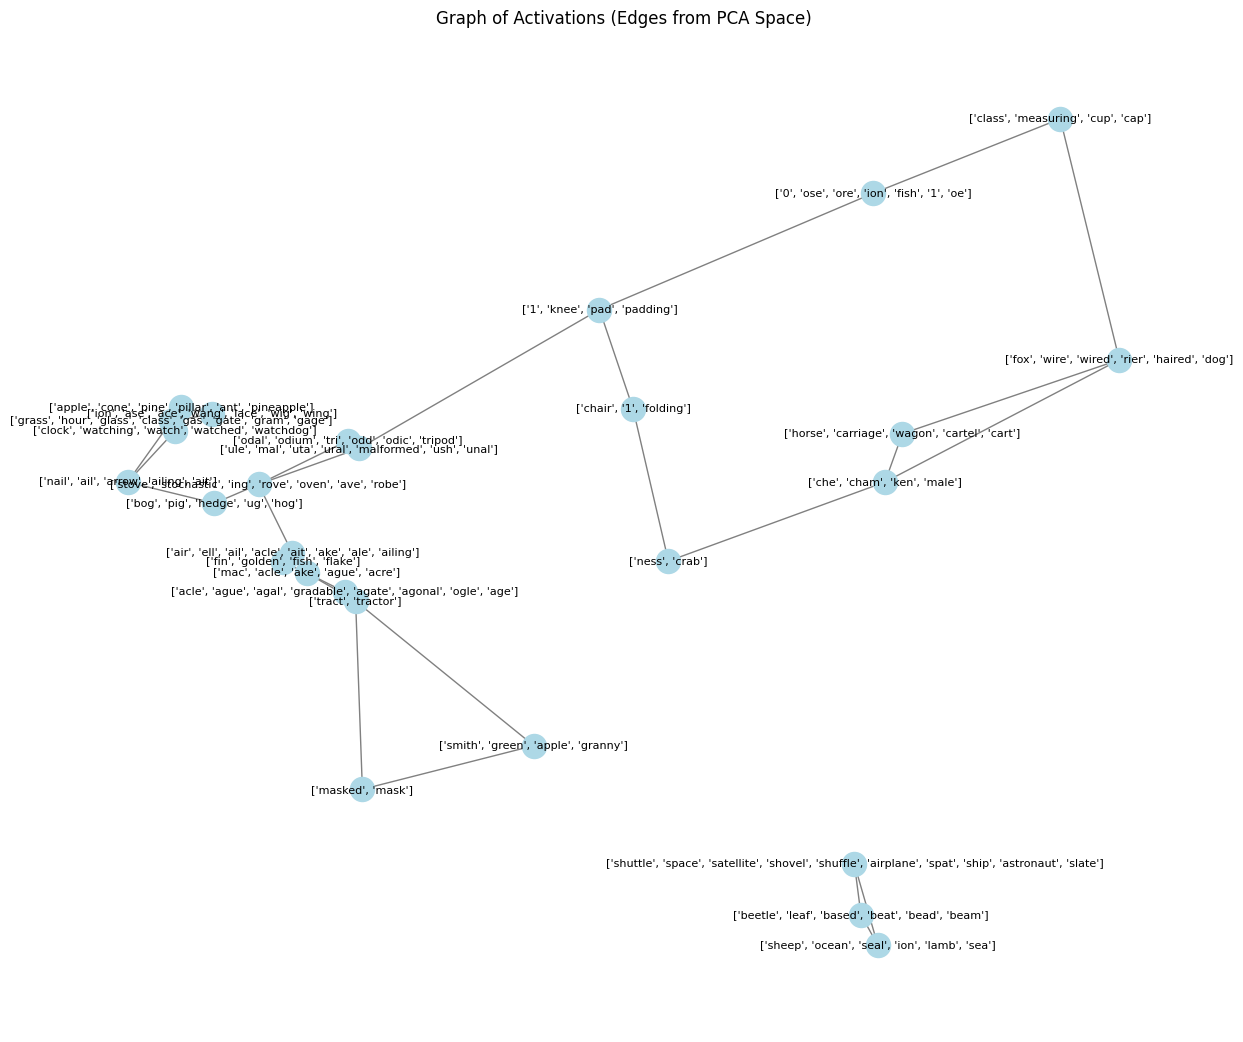

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph

# Inputs:
# X_lap: activation matrix after Laplacian or raw activations
# names: list of node names, length = X_lap.shape[0]

# Step 1: Reduce to 2D with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_lap)

# Step 2: Use distances in PCA space to define edges
# We'll use k-NN here *in PCA space*
knn_graph = kneighbors_graph(X_pca, n_neighbors=2, mode='connectivity', include_self=False)
adj_matrix = knn_graph.toarray()

# Step 3: Create graph
G = nx.from_numpy_array(adj_matrix)
pos = {i: X_pca[i] for i in range(len(X_pca))}  # PCA positions for plotting

# Step 4: Plot
plt.figure(figsize=(12, 10))
nx.draw(G, pos, node_size=300, node_color='lightblue', edge_color='gray', with_labels=False)

# Draw labels (names)
for i, name in enumerate(names):
    x, y = pos[i]
    plt.text(x, y, name, fontsize=8, ha='center', va='center', color='black')

plt.title("Graph of Activations (Edges from PCA Space)")
plt.axis('off')
plt.show()
